# Urban Service Priority Mapping

Combine zone indicators and point observations to rank urban service intervention areas.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by GeoPandas gallery workflows and geodatasets-style educational spatial data; this case uses a local synthetic teaching dataset bundled in data/.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
zones = gpd.read_file(DATA / 'zones.geojson')
obs = pd.read_csv(DATA / 'observations.csv')
points = gpd.GeoDataFrame(obs, geometry=gpd.points_from_xy(obs.lon, obs.lat), crs='EPSG:4326')
print({'zones': len(zones), 'observations': len(points), 'crs': str(zones.crs)})
display(zones.head())


{'zones': 25, 'observations': 100, 'crs': 'EPSG:4326'}


,zone_id,district,score,population,green_ratio,geometry
0,Z0000,District 1,54.788103,11110,0.153872,"POLYGON ((118.725 31.9, 118.725 31.922, 118.7 ..."
1,Z0001,District 1,49.611238,8827,0.175175,"POLYGON ((118.76 31.9, 118.76 31.922, 118.735 ..."
2,Z0002,District 1,42.966962,10732,0.132801,"POLYGON ((118.795 31.9, 118.795 31.922, 118.77..."
3,Z0003,District 1,31.764316,7842,0.114880,"POLYGON ((118.83 31.9, 118.83 31.922, 118.805 ..."
4,Z0004,District 1,32.478711,9434,0.172747,"POLYGON ((118.865 31.9, 118.865 31.922, 118.84..."


In [2]:
joined = gpd.sjoin(points, zones[['zone_id', 'score', 'geometry']], predicate='within', how='left')
summary = joined.groupby('zone_id').agg(mean_value=('value', 'mean'), observations=('id', 'count')).reset_index()
zones2 = zones.merge(summary, on='zone_id', how='left').fillna({'mean_value': 0, 'observations': 0})
zones2['priority_index'] = (zones2['mean_value'] * 0.65 + zones2['score'] * 0.35).round(2)
display(zones2[['zone_id', 'score', 'mean_value', 'observations', 'priority_index']].sort_values('priority_index', ascending=False).head(8))


,zone_id,score,mean_value,observations,priority_index
1,Z0001,49.611238,80.770000,4.0,69.86
6,Z0101,57.906268,74.455000,4.0,68.66
16,Z0301,58.471750,67.545000,2.0,64.37
11,Z0201,57.402439,65.480000,2.0,62.65
0,Z0000,54.788103,65.841667,6.0,61.97
5,Z0100,57.089314,64.515000,4.0,61.92
7,Z0102,40.228391,72.090000,1.0,60.94
12,Z0202,58.876737,61.510000,1.0,60.59


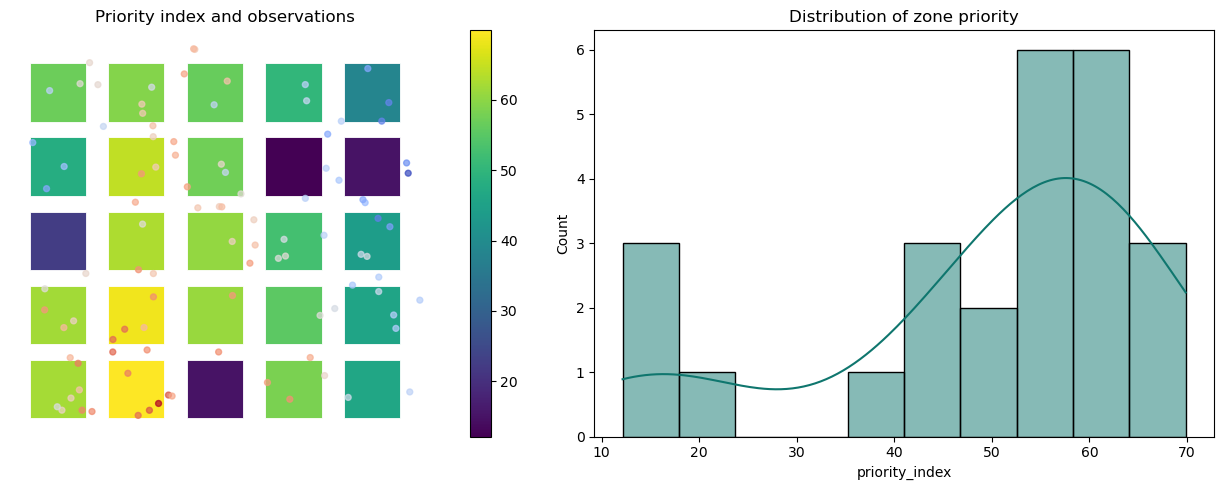

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
zones2.plot(column='priority_index', cmap='viridis', legend=True, ax=axes[0], edgecolor='white', linewidth=0.6)
points.plot(column='value', cmap='coolwarm', markersize=18, alpha=0.72, ax=axes[0])
axes[0].set_title('Priority index and observations')
axes[0].set_axis_off()
sns.histplot(zones2['priority_index'], bins=10, kde=True, ax=axes[1], color='#0f766e')
axes[1].set_title('Distribution of zone priority')
fig.tight_layout()
fig.savefig(OUT / 'priority_map.png', dpi=160)
plt.show()


In [4]:
center = [points.geometry.y.mean(), points.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
folium.Choropleth(
    geo_data=zones2.to_json(), data=zones2, columns=['zone_id', 'priority_index'], key_on='feature.properties.zone_id',
    fill_color='YlOrRd', fill_opacity=0.62, line_opacity=0.3, legend_name='Priority index'
).add_to(m)
for row in points.sample(min(35, len(points)), random_state=7).itertuples():
    folium.CircleMarker([row.lat, row.lon], radius=3, color='#1d4ed8', fill=True, fill_opacity=0.72, popup=f'{row.id}: {row.value}').add_to(m)
m.save(OUT / 'interactive_map.html')
display(m)


In [5]:
top = zones2.sort_values('priority_index', ascending=False).head(5)
print('Top intervention zones:')
for row in top.itertuples():
    print(f'- {row.zone_id}: priority={row.priority_index}, observations={int(row.observations)}')


Top intervention zones:
- Z0001: priority=69.86, observations=4
- Z0101: priority=68.66, observations=4
- Z0301: priority=64.37, observations=2
- Z0201: priority=62.65, observations=2
- Z0000: priority=61.97, observations=6
